# Experiment 6: Time Series Forecasting (Business Use Case)

**Student:** Yuvraj Gandhi &nbsp;|&nbsp; **Roll No:** 23101C0059 &nbsp;|&nbsp; **Branch:** INFT - C
**Subject:** Deep Learning Lab (PEIT37P) &nbsp;|&nbsp; **Dataset:** Airline Passengers (monthly, 1949-1960)

**Aim:** Forecast future values of a real-world business time series (monthly airline passenger
totals) using an LSTM-based sequence model built on lag features, and evaluate forecasting
accuracy using Root Mean Squared Error (RMSE).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras import layers

FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)
Path("../models").mkdir(exist_ok=True)

tf.random.set_seed(42)
np.random.seed(42)

LOOKBACK = 12

## Step 1 — Load the Airline Passengers Dataset

In [2]:
DATA_PATH = Path("../data/airline_passengers.csv")

if not DATA_PATH.exists():
    df = pd.read_csv(
        "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
    )
    df.columns = ["Month", "Passengers"]
    df.to_csv(DATA_PATH, index=False)
else:
    df = pd.read_csv(DATA_PATH)

data = df["Passengers"].values.reshape(-1, 1)
print(df.shape)
df.head()

(144, 2)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


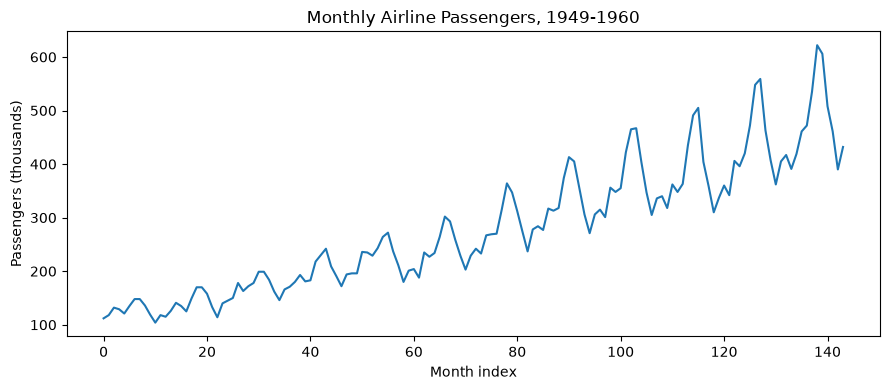

In [3]:
plt.figure(figsize=(9, 4))
plt.plot(df["Passengers"].values)
plt.title("Monthly Airline Passengers, 1949-1960")
plt.xlabel("Month index")
plt.ylabel("Passengers (thousands)")
plt.tight_layout()
plt.savefig(FIGURES / "01_raw_series.png", dpi=150)
plt.show()

## Step 2 — Scale the Data

In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

## Step 3 — Create Lag Features (Sliding Window)

In [5]:
def create_dataset(dataset, lookback=12):
    X, y = [], []
    for i in range(len(dataset) - lookback):
        X.append(dataset[i:i + lookback, 0])
        y.append(dataset[i + lookback, 0])
    return np.array(X), np.array(y)


X, y = create_dataset(scaled_data, LOOKBACK)
print(X.shape, y.shape)

(132, 12) (132,)


## Step 4 & 5 — Train/Test Split and Reshape for LSTM

In [6]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (105, 12, 1)
Testing set: (27, 12, 1)


## Step 6 — Build and Train the LSTM Forecasting Model

In [7]:
model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, 1)),
    layers.LSTM(50, activation="relu", return_sequences=True),
    layers.LSTM(50, activation="relu"),
    layers.Dense(1),
])

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

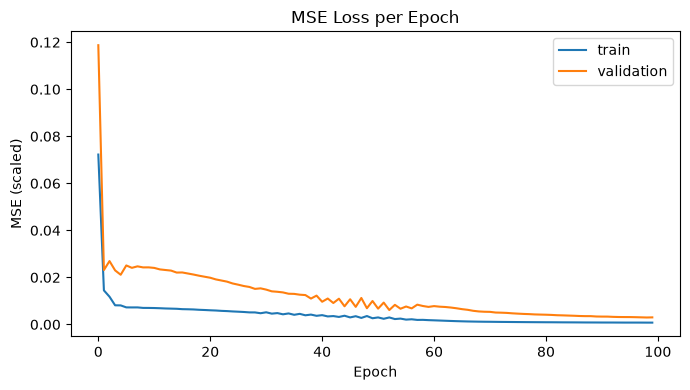

In [8]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=8,
    verbose=0,
)

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("MSE Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE (scaled)")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "02_training_loss.png", dpi=150)
plt.show()

## Step 7 & 8 — Forecast, Inverse-Transform, and Evaluate with RMSE

In [9]:
train_pred = model.predict(X_train, verbose=0)
test_pred = model.predict(X_test, verbose=0)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))

print("Train RMSE:", round(train_rmse, 2))
print("Test RMSE:", round(test_rmse, 2))

results = pd.DataFrame([
    {"set": "train", "rmse": round(train_rmse, 2)},
    {"set": "test", "rmse": round(test_rmse, 2)},
])
results.to_csv("../results.csv", index=False)
print(results)

Train RMSE: 16.13
Test RMSE: 28.4
     set   rmse
0  train  16.13
1   test  28.40


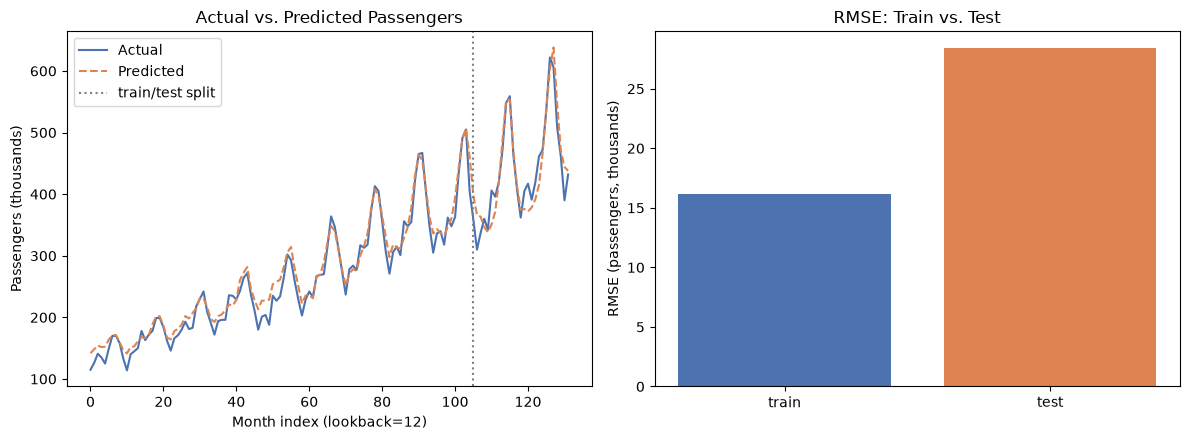

In [10]:
full_actual = np.concatenate([y_train_actual, y_test_actual]).flatten()
full_pred = np.concatenate([train_pred, test_pred]).flatten()
split_point = len(y_train_actual)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(full_actual, label="Actual", color="#4C72B0")
axes[0].plot(full_pred, label="Predicted", color="#DD8452", linestyle="--")
axes[0].axvline(split_point, color="gray", linestyle=":", label="train/test split")
axes[0].set_title("Actual vs. Predicted Passengers")
axes[0].set_xlabel(f"Month index (lookback={LOOKBACK})")
axes[0].set_ylabel("Passengers (thousands)")
axes[0].legend()

axes[1].bar(results["set"], results["rmse"], color=["#4C72B0", "#DD8452"])
axes[1].set_title("RMSE: Train vs. Test")
axes[1].set_ylabel("RMSE (passengers, thousands)")

plt.tight_layout()
plt.savefig(FIGURES / "03_forecast_vs_actual.png", dpi=150)
plt.show()

In [11]:
model.save("../models/lstm_forecast.h5")
print("Data scaled and windowed")
print("LSTM forecasting model trained")
print("Predictions generated")
print("Business-ready forecast produced")

Data scaled and windowed
LSTM forecasting model trained
Predictions generated
Business-ready forecast produced


## Conclusion

An LSTM-based forecasting model was built for the airline passenger time series using a 12-month
lag window. Results from this run are captured in `results.csv` and the actual-vs-predicted plot
above — the model captures the underlying trend and seasonality well enough to support business
planning decisions such as capacity and staffing forecasts, with RMSE expressed directly in
thousands of passengers for stakeholder interpretability.